# Student Performance Analysis


### Name : Sambhav Italiya
### Collage Name : Sutex Bank College of Computer Applications & Science

## Objective :
#### To analyze student performance based on study hours, attendance, gender, and parental education, and predict future scores.

## Importing Libraries :


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Loading Dataset :

In [115]:
df = pd.read_csv("../data/student_performance_dataset.csv")

df # printing data

,student_id,gender,study_hours,attendance,parental_education,math,science,history,english
0,1,Male,1.3,52.6,Diploma,20.0,40.0,36.0,25.0
1,2,Female,6.7,76.6,Graduate,53.0,57.0,53.0,54.0
2,3,Male,3.8,77.0,High School,42.0,44.0,40.0,48.0
3,4,Male,5.6,81.9,High School,47.0,54.0,58.0,NaN
4,5,Male,9.2,86.3,High School,69.0,73.0,67.0,74.0
...,...,...,...,...,...,...,...,...,...
195,196,Female,5.7,67.7,High School,52.0,46.0,60.0,41.0
196,197,Female,7.9,79.2,Diploma,73.0,60.0,59.0,65.0
197,198,Female,2.9,53.9,Graduate,36.0,29.0,36.0,39.0
198,199,Male,6.6,98.7,Graduate,61.0,60.0,69.0,56.0


## Data Understanding :


In [116]:
# For Understanding null value and data type of all columns....

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    int64  
 1   gender              200 non-null    object 
 2   study_hours         190 non-null    float64
 3   attendance          190 non-null    float64
 4   parental_education  200 non-null    object 
 5   math                190 non-null    float64
 6   science             190 non-null    float64
 7   history             190 non-null    float64
 8   english             190 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 14.2+ KB


In [117]:
# For Understanding all numerical columns statistics....

df.describe()

,student_id,study_hours,attendance,math,science,history,english
count,200.000000,190.000000,190.000000,190.000000,190.000000,190.000000,190.000000
mean,100.500000,5.776316,73.619737,51.252632,52.868421,54.568421,54.689474
std,57.879185,3.126676,17.840644,17.408548,16.121843,15.674704,15.763913
min,1.000000,1.000000,15.390000,12.000000,19.000000,14.000000,20.000000
25%,50.750000,3.225000,59.025000,39.000000,44.000000,44.000000,44.000000
50%,100.500000,5.750000,74.950000,52.000000,52.000000,55.000000,54.500000
75%,150.250000,7.975000,87.700000,63.000000,62.000000,63.000000,64.000000
max,200.000000,19.600000,99.600000,100.000000,100.000000,100.000000,100.000000


## Checking Missing Values & Outliers :

### > Outliers is extreme values in columns that very diffrent from other data of column.

#### > Checking subject columns for marks is between 1-100 or not....

##### 1. checking min and max values. Between 1 to 100.
##### 2. Checking 50 % is around the mean. If diffrence is huge than it consider as outliers

In [118]:
# For finding missing values....

df.isnull().sum()

student_id             0
gender                 0
study_hours           10
attendance            10
parental_education     0
math                  10
science               10
history               10
english               10
dtype: int64

#### > So some of columns have missing values like study hours, attendance, and all subject marks..!

In [119]:
# Finding outliers of all subject...

print('-----------------math--------------------')
print(df['math'].describe())

print('-----------------science--------------------')
print(df['science'].describe())

print('-----------------history--------------------')
print(df['history'].describe())

print('-----------------english--------------------')
print(df['english'].describe())



-----------------math--------------------
count    190.000000
mean      51.252632
std       17.408548
min       12.000000
25%       39.000000
50%       52.000000
75%       63.000000
max      100.000000
Name: math, dtype: float64
-----------------science--------------------
count    190.000000
mean      52.868421
std       16.121843
min       19.000000
25%       44.000000
50%       52.000000
75%       62.000000
max      100.000000
Name: science, dtype: float64
-----------------history--------------------
count    190.000000
mean      54.568421
std       15.674704
min       14.000000
25%       44.000000
50%       55.000000
75%       63.000000
max      100.000000
Name: history, dtype: float64
-----------------english--------------------
count    190.000000
mean      54.689474
std       15.763913
min       20.000000
25%       44.000000
50%       54.500000
75%       64.000000
max      100.000000
Name: english, dtype: float64


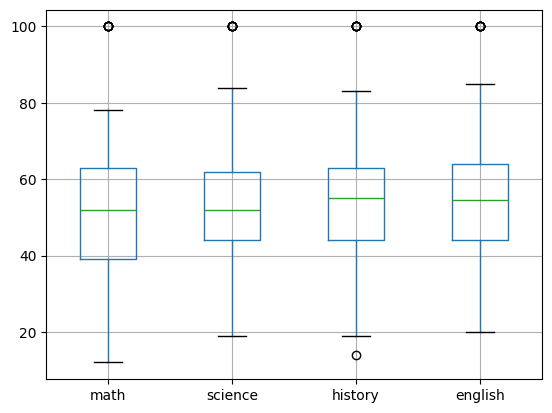

In [120]:
# boxplot of all subjects...

df.boxplot(column=['math','science','history','english'])
plt.show()

In [121]:
df['study_hours'].describe()

count    190.000000
mean       5.776316
std        3.126676
min        1.000000
25%        3.225000
50%        5.750000
75%        7.975000
max       19.600000
Name: study_hours, dtype: float64

In [122]:
sum(df['study_hours'] > 15)  # outliers

3

In [123]:
((df['math'] == 100) & (df['science'] == 100) & (df['history'] == 100) & (df['english'] == 100)).sum() # outliers

np.int64(6)

## Data Cleaning :

### Handle Missing Values....

In [124]:
df.isnull().sum()


student_id             0
gender                 0
study_hours           10
attendance            10
parental_education     0
math                  10
science               10
history               10
english               10
dtype: int64

In [125]:
# Filling missing value using mean of study hours ....

df['study_hours'] = df['study_hours'].fillna(df['study_hours'].mean())

df['study_hours'].isnull().sum()

np.int64(0)

In [126]:
# Filling missing values using mean value of attendance....

df['attendance'] = df['attendance'].fillna(df['attendance'].mean())

df['attendance'].isnull().sum()

np.int64(0)

In [127]:
# Filling missing values using mean of their respective subject ....

df.fillna(df.mean(numeric_only=True), inplace=True)



In [128]:
df.isnull().sum()

student_id            0
gender                0
study_hours           0
attendance            0
parental_education    0
math                  0
science               0
history               0
english               0
dtype: int64

### Removing Outliers...

In [143]:
# rounding the values....


df['science'] = df['science'].round(1)

df['history'] = df['history'].round(1)

df['english'] = df['english'].round(1)

df['study_hours'] = df['study_hours'].round(0)

df.head(4)

,student_id,gender,study_hours,attendance,parental_education,math,science,history,english
0,1,Male,1.0,52.6,Diploma,20.0,40.0,36.0,25.0
1,2,Female,7.0,76.6,Graduate,53.0,57.0,53.0,54.0
2,3,Male,4.0,77.0,High School,42.0,44.0,40.0,48.0
3,4,Male,6.0,81.9,High School,47.0,54.0,58.0,54.7


In [141]:
# Replace the outliers using mean of that column through loc...

mean_value = df['study_hours'].mean()

df.loc[df['study_hours'] > 15, 'study_hours'] = mean_value


df.loc[df['study_hours'] > 15]


,student_id,gender,study_hours,attendance,parental_education,math,science,history,english


In [142]:
# Finding and replacing outliers...

df.loc[(df['math'] > 99) & (df['science'] > 99) & (df['history'] > 99) & (df['english'] > 99)]

,student_id,gender,study_hours,attendance,parental_education,math,science,history,english
12,13,Male,6.0,15.39,Diploma,100.0,100.0,100.0,100.0
60,61,Male,9.0,20.82,High School,100.0,100.0,100.0,100.0
103,104,Female,6.0,27.39,High School,100.0,100.0,100.0,100.0
126,127,Female,6.0,21.63,Postgraduate,100.0,100.0,100.0,100.0
184,185,Male,12.0,23.76,Postgraduate,100.0,100.0,100.0,100.0
194,195,Male,4.0,21.96,Diploma,100.0,100.0,100.0,100.0


In [83]:
# Replace the outliers of each subject using mean of that column through loc...

mean_value = df['math'].mean()

df.loc[df['study_hours'] > 15, 'study_hours'] = mean_value

,student_id,gender,study_hours,attendance,parental_education,math,science,history,english


##### > Missing values were filled using mean values.
##### > Extreme outliers were replacle with their respective mean to improve analysis accuracy.
##### > Now dataset is fully ready for analysis.............

## Feature Engineering :

#### > Adding two new columns for total marks and avrage marks of student....



In [93]:
# Total marks columns.....

df['total_marks'] = df[['math','science','history','english']].sum(axis=1).round(2)

df['total_marks'].head(5)



0    121.00
1    217.00
2    174.00
3    213.69
4    283.00
Name: total_marks, dtype: float64

In [94]:
# Avearge marks columns...

df['average_marks'] = (df['total_marks'] / 4).round(2)

df['average_marks'].tail(7)

193    45.86
194     0.00
195    49.75
196    64.25
197    35.00
198    61.50
199    46.25
Name: average_marks, dtype: float64